# Software-Engineered Chest X-Ray Analysis and Explanation System

**Notebook:** ChestMNIST Data Engineering and Exploratory Analysis  
**Subject:** AIMLCZG546 - Software Engineering for Machine Learning  
**Assessment:** Assignment II  
**Group:** 89

## Group Details & Contribution

| BITS ID | Name | Engineering contribution | Weight |
|---|---|---|---:|
| 2024ac05672@wilp.bits-pilani.ac.in | Ananda Vadivel D | Requirements formulation, GR4ML view preparation, quality requirement justification | 25% |
| 2024ac05968@wilp.bits-pilani.ac.in | Adurti Sai Venkatesh | Dataset preparation, exploratory data analysis, visualization support, data quality validation | 25% |
| 2024ac05653@wilp.bits-pilani.ac.in | D Mallikarjuna Reddy | ML pipeline implementation, model comparison, final evaluation, report integration | 25% |
| 2024ac05055@wilp.bits-pilani.ac.in | Krupashankar Subramani | System architecture, architectural pattern mapping, model registry artifacts, inference and application validation | 25% |

## Notebook Index

1. [ChestMNIST Data Engineering and Exploratory Analysis](#chestmnist-data-engineering-and-exploratory-analysis)
2. [1. Solution Configuration Bootstrap](#1-solution-configuration-bootstrap)
3. [2. ChestMNIST Dataset Specification](#2-chestmnist-dataset-specification)
4. [3. Multilabel Dataset Profiling](#3-multilabel-dataset-profiling)
5. [4. Image-Level Visual Inspection](#4-image-level-visual-inspection)
6. [5. Training Data Preparation](#5-training-data-preparation)
7. [6. Data Profile Artifact Generation](#6-data-profile-artifact-generation)
8. [7. Data Engineering Readiness Gate](#7-data-engineering-readiness-gate)

---

The notebook records the executable implementation, retained runtime outputs, and verifiable engineering evidence for this component.


# ChestMNIST Data Engineering and Exploratory Analysis

This notebook establishes the ChestMNIST data pipeline for the Chest X-Ray Analysis and Explanation Assistant. It covers solution configuration, dataset acquisition, integrity validation, multilabel profiling, exploratory analysis and preparation of reproducible data loaders.

ChestMNIST outputs are used strictly for research and educational demonstration. They must not be interpreted as clinical diagnoses or replacements for professional medical assessment.


## 1. Solution Configuration Bootstrap

The centralized path registry is loaded to ensure that datasets, caches, generated outputs and reusable solution components are consistently routed to their approved storage locations.


In [1]:
from pathlib import Path
import yaml

PATH_CONFIG_FILE = (
    Path.home()
    / "chest-xray-ai-assistant"
    / "configs"
    / "paths.yaml"
)

if not PATH_CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Path configuration was not found: {PATH_CONFIG_FILE}"
    )

with PATH_CONFIG_FILE.open("r", encoding="utf-8") as file:
    path_config = yaml.safe_load(file)

SOLUTION_ROOT = Path(path_config["solution"]["root"])
DATA_ROOT = Path(path_config["data"]["root"])
RAW_DATA_PATH = Path(path_config["data"]["raw"])
PROCESSED_DATA_PATH = Path(path_config["data"]["processed"])
OUTPUTS_PATH = Path(path_config["data"]["outputs"])

print("SOLUTION CONFIGURATION")
print("-" * 100)
print(f"{'Configuration file':<25}: {PATH_CONFIG_FILE}")
print(f"{'Solution root':<25}: {SOLUTION_ROOT}")
print(f"{'Data root':<25}: {DATA_ROOT}")
print(f"{'Raw data path':<25}: {RAW_DATA_PATH}")
print(f"{'Processed data path':<25}: {PROCESSED_DATA_PATH}")
print(f"{'Outputs path':<25}: {OUTPUTS_PATH}")

SOLUTION CONFIGURATION
----------------------------------------------------------------------------------------------------
Configuration file       : /home/jovyan/chest-xray-ai-assistant/configs/paths.yaml
Solution root            : /home/jovyan/chest-xray-ai-assistant
Data root                : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data
Raw data path            : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/raw
Processed data path      : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/processed
Outputs path             : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs


### 1.1 Runtime Storage Routing

Runtime caches and experiment artifacts are routed to the dedicated data volume before any dataset or model resources are accessed.


In [2]:
import os

runtime_routes = {
    "HF_HOME": path_config["cache"]["huggingface"],
    "HF_DATASETS_CACHE": str(
        Path(path_config["cache"]["huggingface"]) / "datasets"
    ),
    "TORCH_HOME": path_config["cache"]["torch"],
    "PIP_CACHE_DIR": path_config["cache"]["pip"],
    "MLFLOW_TRACKING_URI": Path(
        path_config["data"]["mlflow"]
    ).as_uri(),
    "TOKENIZERS_PARALLELISM": "false",
}

for variable_name, variable_value in runtime_routes.items():
    os.environ[variable_name] = variable_value

Path(runtime_routes["HF_DATASETS_CACHE"]).mkdir(
    parents=True,
    exist_ok=True,
)

print("RUNTIME STORAGE ROUTING")
print("-" * 110)

for variable_name, variable_value in runtime_routes.items():
    print(f"{variable_name:<25}: {variable_value}")

RUNTIME STORAGE ROUTING
--------------------------------------------------------------------------------------------------------------
HF_HOME                  : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/hf-cache
HF_DATASETS_CACHE        : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/hf-cache/datasets
TORCH_HOME               : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/models/torch-cache
PIP_CACHE_DIR            : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/pip-cache
MLFLOW_TRACKING_URI      : file:///home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/mlflow
TOKENIZERS_PARALLELISM   : false


## 2. ChestMNIST Dataset Specification

ChestMNIST provides frontal chest X-ray images with 14 independently encoded target findings. The solution uses the official training, validation and test partitions to preserve reproducibility and prevent evaluation leakage.

The 224 × 224 MedMNIST+ variant is selected to retain more visual information for transfer learning and finding-specific Grad-CAM generation.


In [3]:
import medmnist
from medmnist import INFO

DATASET_FLAG = "chestmnist"
IMAGE_SIZE = 224

dataset_info = INFO[DATASET_FLAG]
dataset_class = getattr(
    medmnist,
    dataset_info["python_class"],
)

label_map = {
    int(label_id): label_name
    for label_id, label_name in dataset_info["label"].items()
}

split_sizes = dataset_info["n_samples"]
total_samples = sum(split_sizes.values())

print("CHESTMNIST DATASET SPECIFICATION")
print("-" * 100)
print(f"{'Dataset flag':<25}: {DATASET_FLAG}")
print(f"{'Python class':<25}: {dataset_info['python_class']}")
print(f"{'Task type':<25}: {dataset_info['task']}")
print(f"{'Image resolution':<25}: {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"{'Image channels':<25}: {dataset_info['n_channels']}")
print(f"{'Number of labels':<25}: {len(label_map)}")
print(f"{'Training samples':<25}: {split_sizes['train']:,}")
print(f"{'Validation samples':<25}: {split_sizes['val']:,}")
print(f"{'Test samples':<25}: {split_sizes['test']:,}")
print(f"{'Total samples':<25}: {total_samples:,}")

print("\nTARGET FINDINGS")
print("-" * 100)

for label_id, label_name in label_map.items():
    print(f"{label_id:>2}: {label_name}")

CHESTMNIST DATASET SPECIFICATION
----------------------------------------------------------------------------------------------------
Dataset flag             : chestmnist
Python class             : ChestMNIST
Task type                : multi-label, binary-class
Image resolution         : 224 × 224
Image channels           : 1
Number of labels         : 14
Training samples         : 78,468
Validation samples       : 11,219
Test samples             : 22,433
Total samples            : 112,120

TARGET FINDINGS
----------------------------------------------------------------------------------------------------
 0: atelectasis
 1: cardiomegaly
 2: effusion
 3: infiltration
 4: mass
 5: nodule
 6: pneumonia
 7: pneumothorax
 8: consolidation
 9: edema
10: emphysema
11: fibrosis
12: pleural
13: hernia


### 2.1 Dataset Acquisition Readiness

The expected ChestMNIST+ storage footprint is evaluated before acquisition. A reserve is maintained for processed data, model checkpoints, experiment artifacts and explainability outputs.


In [4]:
import shutil

dataset_file = (
    RAW_DATA_PATH
    / f"{DATASET_FLAG}_{IMAGE_SIZE}.npz"
)

bytes_per_image = (
    IMAGE_SIZE
    * IMAGE_SIZE
    * dataset_info["n_channels"]
)

estimated_image_bytes = total_samples * bytes_per_image
estimated_image_gib = estimated_image_bytes / (1024 ** 3)

available_data_gib = (
    shutil.disk_usage(DATA_ROOT).free / (1024 ** 3)
)

minimum_reserve_gib = 4.0
estimated_required_gib = (
    estimated_image_gib * 2
    + minimum_reserve_gib
)

storage_ready = available_data_gib >= estimated_required_gib

print("DATASET ACQUISITION READINESS")
print("-" * 100)
print(f"{'Target dataset file':<32}: {dataset_file}")
print(f"{'Dataset already available':<32}: {dataset_file.exists()}")
print(f"{'Estimated raw image arrays':<32}: {estimated_image_gib:.2f} GiB")
print(f"{'Available data-volume space':<32}: {available_data_gib:.2f} GiB")
print(f"{'Protected storage reserve':<32}: {minimum_reserve_gib:.2f} GiB")
print(f"{'Storage readiness':<32}: {'PASS' if storage_ready else 'FAIL'}")

DATASET ACQUISITION READINESS
----------------------------------------------------------------------------------------------------
Target dataset file             : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/raw/chestmnist_224.npz
Dataset already available       : False
Estimated raw image arrays      : 5.24 GiB
Available data-volume space     : 20.67 GiB
Protected storage reserve       : 4.00 GiB
Storage readiness               : PASS


### 2.2 Official Dataset Acquisition

The ChestMNIST+ archive is acquired through the official MedMNIST interface. The library validates the downloaded archive against its published checksum and preserves the official dataset partitions.


In [5]:
if not storage_ready:
    raise RuntimeError(
        "Insufficient data-volume capacity for ChestMNIST+ acquisition."
    )

download_probe = dataset_class(
    split="train",
    root=str(RAW_DATA_PATH),
    size=IMAGE_SIZE,
    download=True,
    mmap_mode="r",
)

dataset_size_gib = (
    dataset_file.stat().st_size / (1024 ** 3)
)

print("CHESTMNIST ACQUISITION")
print("-" * 100)
print(f"{'Dataset file':<28}: {dataset_file}")
print(f"{'Download verified':<28}: {dataset_file.exists()}")
print(f"{'Archive size':<28}: {dataset_size_gib:.2f} GiB")
print(f"{'Training records accessible':<28}: {len(download_probe):,}")

del download_probe

100%|██████████| 3.89G/3.89G [1:11:09<00:00, 911kB/s]  


CHESTMNIST ACQUISITION
----------------------------------------------------------------------------------------------------
Dataset file                : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/raw/chestmnist_224.npz
Download verified           : True
Archive size                : 3.62 GiB
Training records accessible : 78,468


### 2.3 Archive and Split Integrity

The training, validation and test partitions are validated against the official sample counts, image dimensions, label dimensions and binary multilabel encoding. Each partition is released from memory after validation.


In [7]:
import gc
import numpy as np

split_validation = {}

print("CHESTMNIST SPLIT INTEGRITY")
print("-" * 115)
print(
    f"{'Split':<12}"
    f"{'Images':>12}"
    f"{'Image shape':>24}"
    f"{'Label shape':>20}"
    f"{'Label values':>20}"
    f"{'Status':>12}"
)
print("-" * 115)

for split_name, expected_count in split_sizes.items():
    split_dataset = dataset_class(
        split=split_name,
        root=str(RAW_DATA_PATH),
        size=IMAGE_SIZE,
        download=False,
        mmap_mode="r",
    )

    image_shape = split_dataset.imgs.shape
    label_shape = split_dataset.labels.shape
    label_values = np.unique(split_dataset.labels).tolist()

    split_valid = (
        len(split_dataset) == expected_count
        and image_shape[0] == expected_count
        and image_shape[1:] == (IMAGE_SIZE, IMAGE_SIZE)
        and label_shape == (expected_count, len(label_map))
        and set(label_values).issubset({0, 1})
    )

    split_validation[split_name] = split_valid

    print(
        f"{split_name:<12}"
        f"{len(split_dataset):>12,}"
        f"{str(image_shape):>24}"
        f"{str(label_shape):>20}"
        f"{str(label_values):>20}"
        f"{'PASS' if split_valid else 'FAIL':>12}"
    )

    del split_dataset
    gc.collect()

print("-" * 115)
print(
    "OVERALL STATUS: "
    + (
        "PASS"
        if all(split_validation.values())
        else "FAIL"
    )
)

CHESTMNIST SPLIT INTEGRITY
-------------------------------------------------------------------------------------------------------------------
Split             Images             Image shape         Label shape        Label values      Status
-------------------------------------------------------------------------------------------------------------------
train             78,468       (78468, 224, 224)         (78468, 14)              [0, 1]        PASS
val               11,219       (11219, 224, 224)         (11219, 14)              [0, 1]        PASS
test              22,433       (22433, 224, 224)         (22433, 14)              [0, 1]        PASS
-------------------------------------------------------------------------------------------------------------------
OVERALL STATUS: PASS


## 3. Multilabel Dataset Profiling

### 3.1 Label Matrix Extraction

The official label matrices are extracted independently from the image arrays. This enables efficient multilabel analysis without loading more than five GiB of image data into system memory.


In [8]:
with np.load(dataset_file, allow_pickle=False) as archive:
    archive_keys = archive.files

    labels_by_split = {
        "train": archive["train_labels"].astype(np.uint8),
        "val": archive["val_labels"].astype(np.uint8),
        "test": archive["test_labels"].astype(np.uint8),
    }

label_memory_mib = sum(
    labels.nbytes
    for labels in labels_by_split.values()
) / (1024 ** 2)

print("LABEL MATRIX EXTRACTION")
print("-" * 100)
print(f"{'Archive keys':<25}: {', '.join(archive_keys)}")

for split_name, labels in labels_by_split.items():
    print(
        f"{split_name.capitalize() + ' labels':<25}: "
        f"Shape {labels.shape}, dtype {labels.dtype}"
    )

print(f"{'Total label memory':<25}: {label_memory_mib:.2f} MiB")

LABEL MATRIX EXTRACTION
----------------------------------------------------------------------------------------------------
Archive keys             : train_images, train_labels, val_images, val_labels, test_images, test_labels
Train labels             : Shape (78468, 14), dtype uint8
Val labels               : Shape (11219, 14), dtype uint8
Test labels              : Shape (22433, 14), dtype uint8
Total label memory       : 1.50 MiB


### 3.2 Finding Prevalence Analysis

Per-finding prevalence is measured across the training, validation and test partitions. Multilabel chest X-ray datasets commonly contain substantial class imbalance, making raw accuracy unsuitable as the primary performance measure.


In [9]:
import pandas as pd

prevalence_records = []

for label_id, finding_name in label_map.items():
    record = {
        "Label ID": label_id,
        "Finding": finding_name,
    }

    for split_name, labels in labels_by_split.items():
        positive_count = int(labels[:, label_id].sum())
        prevalence_pct = (
            positive_count / len(labels)
        ) * 100

        record[f"{split_name.capitalize()} positives"] = positive_count
        record[f"{split_name.capitalize()} prevalence (%)"] = round(
            prevalence_pct,
            2,
        )

    prevalence_records.append(record)

prevalence_df = pd.DataFrame(prevalence_records)

display(
    prevalence_df.style
    .format(
        {
            "Train positives": "{:,}",
            "Val positives": "{:,}",
            "Test positives": "{:,}",
            "Train prevalence (%)": "{:.2f}",
            "Val prevalence (%)": "{:.2f}",
            "Test prevalence (%)": "{:.2f}",
        }
    )
    .hide(axis="index")
)

Label ID,Finding,Train positives,Train prevalence (%),Val positives,Val prevalence (%),Test positives,Test prevalence (%)
0,atelectasis,"7,996",10.19,"1,119",9.97,"2,420",10.79
1,cardiomegaly,"1,950",2.49,240,2.14,582,2.59
2,effusion,"9,261",11.80,"1,292",11.52,"2,754",12.28
3,infiltration,"13,914",17.73,"2,018",17.99,"3,938",17.55
4,mass,"3,988",5.08,625,5.57,"1,133",5.05
5,nodule,"4,375",5.58,613,5.46,"1,335",5.95
6,pneumonia,978,1.25,133,1.19,242,1.08
7,pneumothorax,"3,705",4.72,504,4.49,"1,089",4.85
8,consolidation,"3,263",4.16,447,3.98,957,4.27
9,edema,"1,690",2.15,200,1.78,413,1.84


### 3.3 Finding Prevalence Visualization

The training-set prevalence of each target finding is visualized to communicate the degree of class imbalance and support the subsequent loss-weighting strategy.


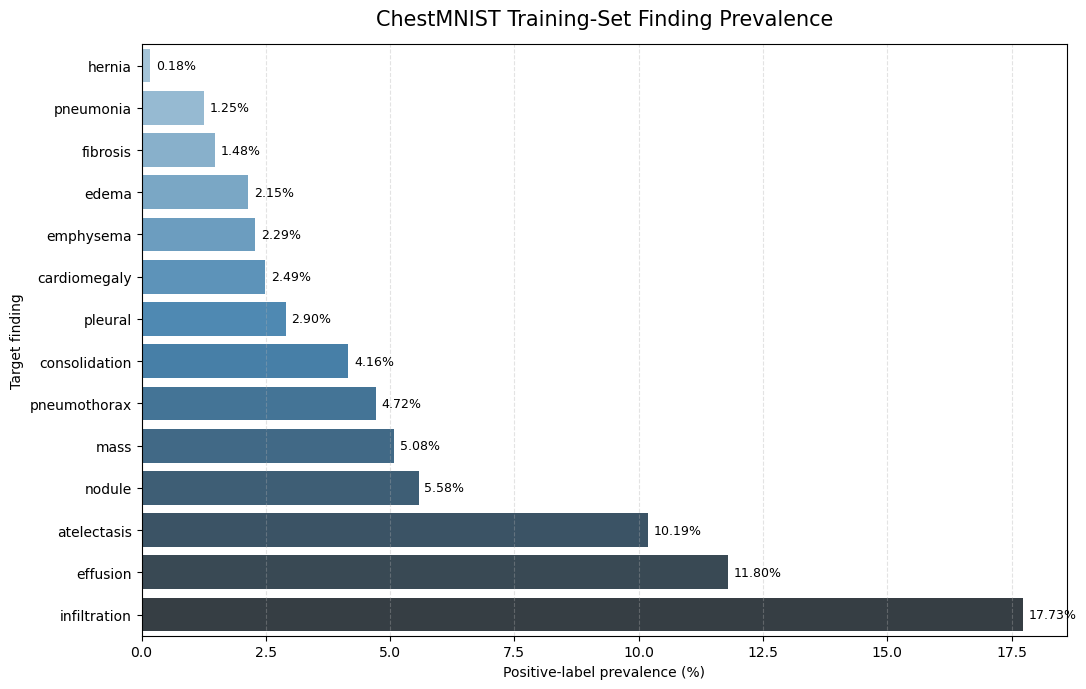

Chart saved: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/charts/chestmnist_training_prevalence.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

charts_path = OUTPUTS_PATH / "charts"
charts_path.mkdir(parents=True, exist_ok=True)

plot_data = prevalence_df.sort_values(
    "Train prevalence (%)",
    ascending=True,
)

plt.figure(figsize=(11, 7))

axis = sns.barplot(
    data=plot_data,
    x="Train prevalence (%)",
    y="Finding",
    hue="Finding",
    palette="Blues_d",
    legend=False,
)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=9,
    )

axis.set_title(
    "ChestMNIST Training-Set Finding Prevalence",
    fontsize=15,
    pad=14,
)
axis.set_xlabel("Positive-label prevalence (%)")
axis.set_ylabel("Target finding")
axis.grid(axis="x", linestyle="--", alpha=0.35)

plt.tight_layout()

prevalence_chart_path = (
    charts_path
    / "chestmnist_training_prevalence.png"
)

plt.savefig(
    prevalence_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {prevalence_chart_path}")

### 3.4 Multilabel Cardinality Profile

Multilabel cardinality measures the number of positive target findings associated with each image. Images with an all-zero label vector are treated as having no recorded target finding; this does not establish a clinically verified normal result.


In [11]:
cardinality_records = []
cardinality_by_split = {}

for split_name, labels in labels_by_split.items():
    finding_count_per_image = labels.sum(axis=1)
    cardinality_by_split[split_name] = finding_count_per_image

    total_count = len(finding_count_per_image)
    zero_count = int((finding_count_per_image == 0).sum())
    single_count = int((finding_count_per_image == 1).sum())
    multiple_count = int((finding_count_per_image >= 2).sum())

    cardinality_records.append(
        {
            "Split": split_name.capitalize(),
            "Images": total_count,
            "No target finding": zero_count,
            "No target finding (%)": round(
                zero_count / total_count * 100,
                2,
            ),
            "One finding": single_count,
            "One finding (%)": round(
                single_count / total_count * 100,
                2,
            ),
            "Multiple findings": multiple_count,
            "Multiple findings (%)": round(
                multiple_count / total_count * 100,
                2,
            ),
            "Mean findings per image": round(
                finding_count_per_image.mean(),
                3,
            ),
            "Maximum findings": int(
                finding_count_per_image.max()
            ),
        }
    )

cardinality_df = pd.DataFrame(cardinality_records)

display(
    cardinality_df.style
    .format(
        {
            "Images": "{:,}",
            "No target finding": "{:,}",
            "One finding": "{:,}",
            "Multiple findings": "{:,}",
            "No target finding (%)": "{:.2f}",
            "One finding (%)": "{:.2f}",
            "Multiple findings (%)": "{:.2f}",
            "Mean findings per image": "{:.3f}",
        }
    )
    .hide(axis="index")
)

Split,Images,No target finding,No target finding (%),One finding,One finding (%),Multiple findings,Multiple findings (%),Mean findings per image,Maximum findings
Train,"78,468","42,405",54.04,"21,602",27.53,"14,461",18.43,0.720,9
Val,"11,219","6,079",54.18,"3,112",27.74,"2,028",18.08,0.711,6
Test,"22,433","11,928",53.17,"6,259",27.90,"4,246",18.93,0.736,7


### 3.5 Finding Cardinality Distribution

The number of recorded target findings per training image is visualized to show the balance between zero-label, single-label and multi-finding cases.


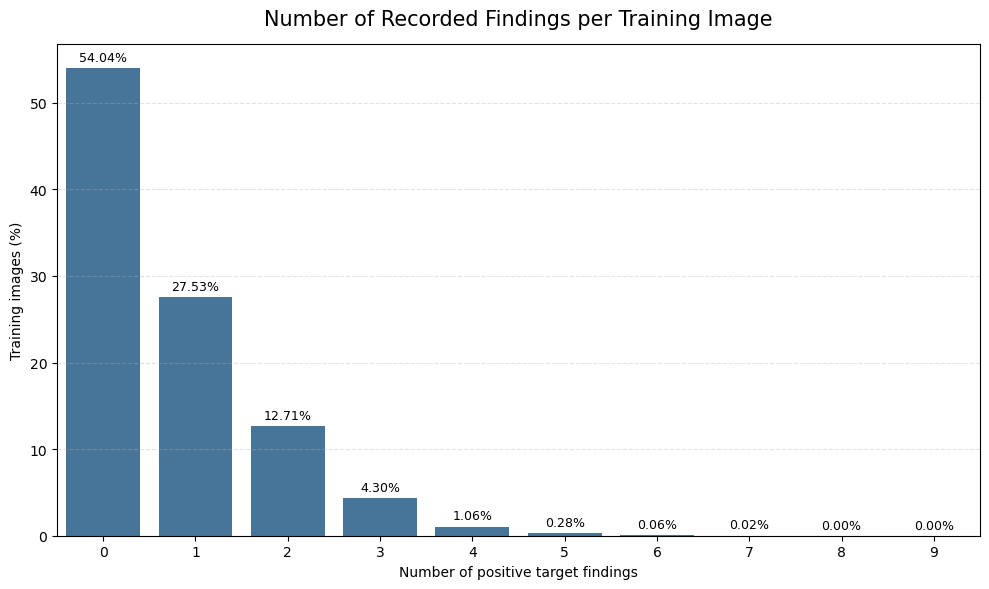

Chart saved: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/charts/chestmnist_finding_cardinality.png


In [12]:
train_cardinality = cardinality_by_split["train"]

cardinality_distribution = (
    pd.Series(train_cardinality)
    .value_counts()
    .sort_index()
    .rename_axis("Finding count")
    .reset_index(name="Images")
)

cardinality_distribution["Percentage"] = (
    cardinality_distribution["Images"]
    / len(train_cardinality)
    * 100
)

plt.figure(figsize=(10, 6))

axis = sns.barplot(
    data=cardinality_distribution,
    x="Finding count",
    y="Percentage",
    color="#3976A8",
)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
        fontsize=9,
    )

axis.set_title(
    "Number of Recorded Findings per Training Image",
    fontsize=15,
    pad=14,
)
axis.set_xlabel("Number of positive target findings")
axis.set_ylabel("Training images (%)")
axis.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()

cardinality_chart_path = (
    charts_path
    / "chestmnist_finding_cardinality.png"
)

plt.savefig(
    cardinality_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {cardinality_chart_path}")

### 3.6 Finding Co-occurrence Analysis

Pairwise label relationships are evaluated using Jaccard association, defined as the number of images containing both findings divided by the number containing either finding. The analysis is descriptive and does not imply a clinical or causal relationship.


In [13]:
train_labels_int = labels_by_split["train"].astype(np.int32)

intersection_matrix = (
    train_labels_int.T @ train_labels_int
)

positive_totals = train_labels_int.sum(axis=0)

union_matrix = (
    positive_totals[:, None]
    + positive_totals[None, :]
    - intersection_matrix
)

jaccard_matrix = np.divide(
    intersection_matrix,
    union_matrix,
    out=np.zeros_like(
        intersection_matrix,
        dtype=np.float64,
    ),
    where=union_matrix != 0,
)

pair_records = []

for first_id in range(len(label_map)):
    for second_id in range(first_id + 1, len(label_map)):
        pair_records.append(
            {
                "Finding 1": label_map[first_id],
                "Finding 2": label_map[second_id],
                "Co-occurring images": int(
                    intersection_matrix[first_id, second_id]
                ),
                "Jaccard association (%)": round(
                    jaccard_matrix[first_id, second_id] * 100,
                    2,
                ),
            }
        )

top_cooccurrence_df = (
    pd.DataFrame(pair_records)
    .sort_values(
        "Jaccard association (%)",
        ascending=False,
    )
    .head(10)
    .reset_index(drop=True)
)

display(
    top_cooccurrence_df.style
    .format(
        {
            "Co-occurring images": "{:,}",
            "Jaccard association (%)": "{:.2f}",
        }
    )
    .hide(axis="index")
)

Finding 1,Finding 2,Co-occurring images,Jaccard association (%)
atelectasis,effusion,"2,226",14.81
effusion,infiltration,"2,801",13.75
atelectasis,infiltration,"2,281",11.62
pneumothorax,emphysema,539,10.86
pneumonia,edema,246,10.16
mass,nodule,605,7.80
atelectasis,consolidation,813,7.78
effusion,consolidation,896,7.71
cardiomegaly,effusion,741,7.08
effusion,mass,865,6.98


### 3.7 Finding Association Heatmap

The complete pairwise Jaccard association matrix is visualized to provide a consolidated view of finding co-occurrence patterns. Self-associations are excluded so that relationships between different findings remain visible.


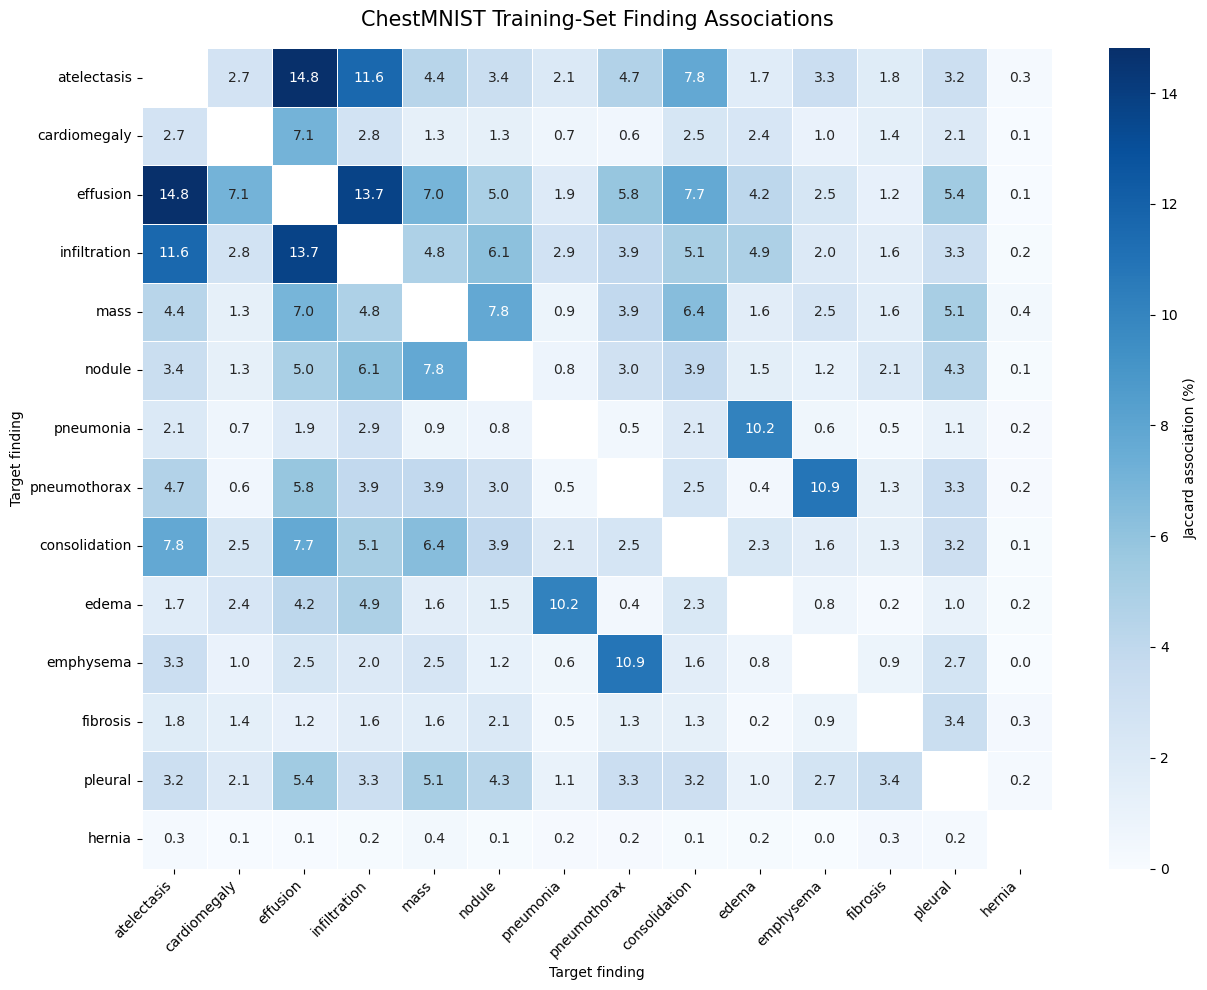

Chart saved: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/charts/chestmnist_finding_associations.png


In [14]:
finding_names = [
    label_map[label_id]
    for label_id in range(len(label_map))
]

jaccard_percent = jaccard_matrix * 100
diagonal_mask = np.eye(
    len(finding_names),
    dtype=bool,
)

plt.figure(figsize=(13, 10))

axis = sns.heatmap(
    jaccard_percent,
    mask=diagonal_mask,
    xticklabels=finding_names,
    yticklabels=finding_names,
    cmap="Blues",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={
        "label": "Jaccard association (%)",
    },
)

axis.set_title(
    "ChestMNIST Training-Set Finding Associations",
    fontsize=15,
    pad=16,
)
axis.set_xlabel("Target finding")
axis.set_ylabel("Target finding")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

association_chart_path = (
    charts_path
    / "chestmnist_finding_associations.png"
)

plt.savefig(
    association_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {association_chart_path}")

## 4. Image-Level Visual Inspection

### 4.1 Representative Sample Selection

Representative training samples are selected using reproducible label-based criteria. The selection covers images with no recorded target finding, individual findings and multiple simultaneous findings.


In [15]:
train_labels = labels_by_split["train"]
train_cardinality = cardinality_by_split["train"]

selection_criteria = {
    "No target finding": train_cardinality == 0,
    "Single atelectasis": (
        (train_labels[:, 0] == 1)
        & (train_cardinality == 1)
    ),
    "Single cardiomegaly": (
        (train_labels[:, 1] == 1)
        & (train_cardinality == 1)
    ),
    "Single effusion": (
        (train_labels[:, 2] == 1)
        & (train_cardinality == 1)
    ),
    "Single pneumonia": (
        (train_labels[:, 6] == 1)
        & (train_cardinality == 1)
    ),
    "Multiple findings": train_cardinality >= 3,
}

selected_samples = []

for sample_type, selection_mask in selection_criteria.items():
    matching_indices = np.flatnonzero(selection_mask)

    if len(matching_indices) == 0:
        continue

    sample_index = int(matching_indices[0])
    active_label_ids = np.flatnonzero(
        train_labels[sample_index]
    )

    finding_list = [
        label_map[int(label_id)]
        for label_id in active_label_ids
    ]

    selected_samples.append(
        {
            "Sample type": sample_type,
            "Training index": sample_index,
            "Finding count": len(finding_list),
            "Recorded findings": (
                ", ".join(finding_list)
                if finding_list
                else "None"
            ),
        }
    )

selected_samples_df = pd.DataFrame(selected_samples)

display(
    selected_samples_df.style
    .hide(axis="index")
)

Sample type,Training index,Finding count,Recorded findings
No target finding,0,0,None
Single atelectasis,30,1,atelectasis
Single cardiomegaly,13,1,cardiomegaly
Single effusion,32,1,effusion
Single pneumonia,215,1,pneumonia
Multiple findings,6,4,"infiltration, pneumothorax, consolidation, emphysema"


### 4.2 Representative Chest X-Ray Gallery

The selected samples are visualized to verify image orientation, grayscale quality and label presentation before preprocessing and model training.


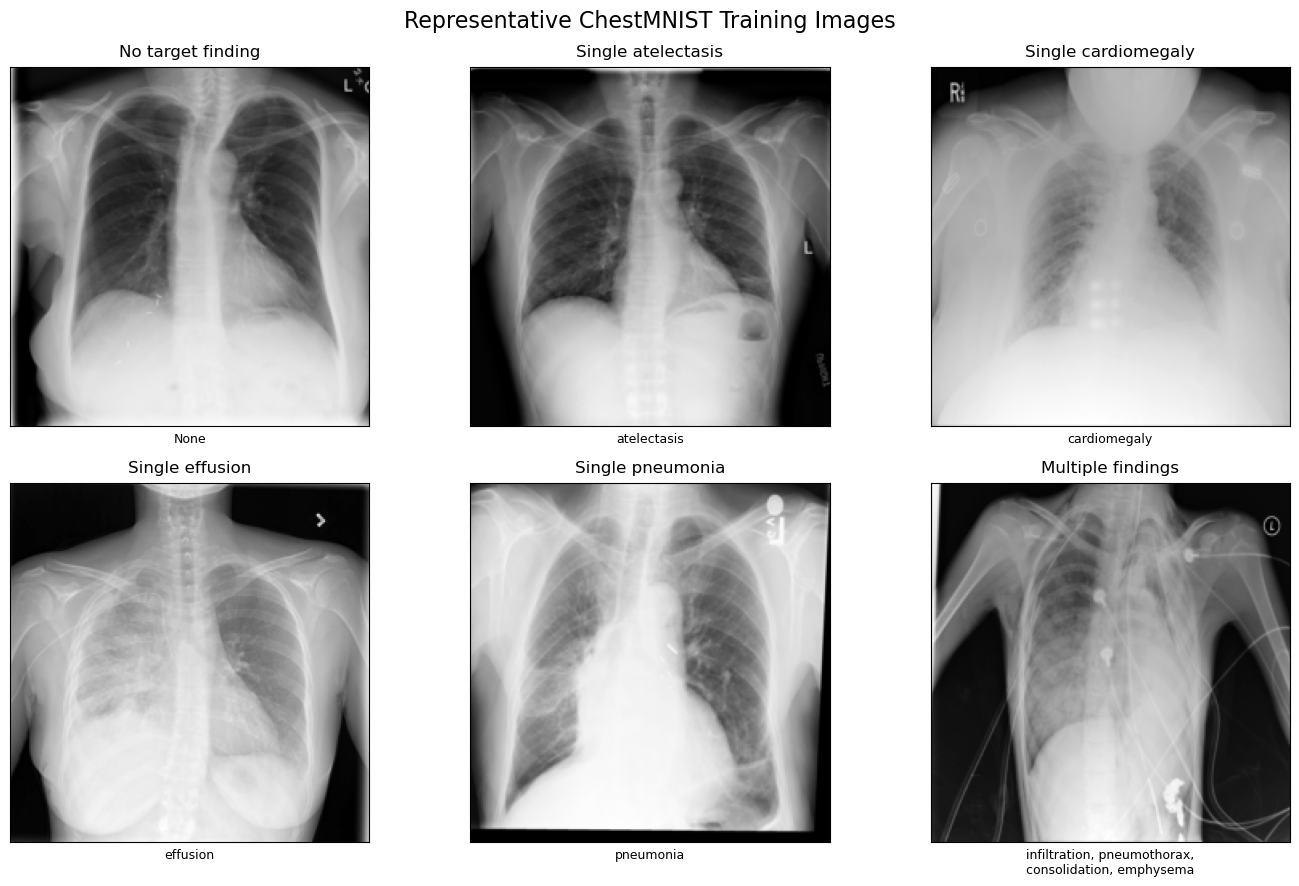

Gallery saved: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/charts/chestmnist_representative_samples.png


16938

In [16]:
import gc
import textwrap

train_visual_dataset = dataset_class(
    split="train",
    root=str(RAW_DATA_PATH),
    size=IMAGE_SIZE,
    download=False,
    mmap_mode="r",
)

figure, axes = plt.subplots(
    2,
    3,
    figsize=(14, 9),
)

for axis, sample in zip(
    axes.flatten(),
    selected_samples,
):
    sample_index = sample["Training index"]
    image, target = train_visual_dataset[sample_index]

    axis.imshow(image, cmap="gray")
    axis.set_title(
        sample["Sample type"],
        fontsize=12,
        pad=8,
    )
    axis.set_xlabel(
        textwrap.fill(
            sample["Recorded findings"],
            width=32,
        ),
        fontsize=9,
    )
    axis.set_xticks([])
    axis.set_yticks([])

figure.suptitle(
    "Representative ChestMNIST Training Images",
    fontsize=16,
    y=0.98,
)

plt.tight_layout()

sample_gallery_path = (
    charts_path
    / "chestmnist_representative_samples.png"
)

plt.savefig(
    sample_gallery_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Gallery saved: {sample_gallery_path}")

del train_visual_dataset
gc.collect()

## 5. Training Data Preparation

### 5.1 Positive-Class Weight Calculation

Label-specific positive weights are calculated from the training partition for use with binary cross-entropy loss. The weights increase the contribution of rare positive findings while a controlled upper limit protects training stability.


In [17]:
MAX_POSITIVE_WEIGHT = 100.0

train_positive_counts = train_labels.sum(axis=0).astype(np.float64)
train_negative_counts = (
    len(train_labels) - train_positive_counts
)

raw_positive_weights = (
    train_negative_counts / train_positive_counts
)

capped_positive_weights = np.clip(
    raw_positive_weights,
    a_min=1.0,
    a_max=MAX_POSITIVE_WEIGHT,
)

positive_weight_df = pd.DataFrame(
    {
        "Label ID": list(label_map.keys()),
        "Finding": list(label_map.values()),
        "Positive samples": train_positive_counts.astype(int),
        "Negative samples": train_negative_counts.astype(int),
        "Raw positive weight": raw_positive_weights,
        "Capped positive weight": capped_positive_weights,
        "Weight capped": (
            raw_positive_weights > MAX_POSITIVE_WEIGHT
        ),
    }
)

display(
    positive_weight_df.style
    .format(
        {
            "Positive samples": "{:,}",
            "Negative samples": "{:,}",
            "Raw positive weight": "{:.2f}",
            "Capped positive weight": "{:.2f}",
        }
    )
    .hide(axis="index")
)

Label ID,Finding,Positive samples,Negative samples,Raw positive weight,Capped positive weight,Weight capped
0,atelectasis,"7,996","70,472",8.81,8.81,False
1,cardiomegaly,"1,950","76,518",39.24,39.24,False
2,effusion,"9,261","69,207",7.47,7.47,False
3,infiltration,"13,914","64,554",4.64,4.64,False
4,mass,"3,988","74,480",18.68,18.68,False
5,nodule,"4,375","74,093",16.94,16.94,False
6,pneumonia,978,"77,490",79.23,79.23,False
7,pneumothorax,"3,705","74,763",20.18,20.18,False
8,consolidation,"3,263","75,205",23.05,23.05,False
9,edema,"1,690","76,778",45.43,45.43,False


### 5.2 Image Preprocessing and Augmentation

The preprocessing pipeline converts grayscale chest X-rays into the three-channel representation required by the pretrained ResNet-18 backbone. Training augmentation introduces controlled acquisition variability while preserving anatomical orientation and image coverage.

Validation and test images receive deterministic preprocessing to ensure reproducible evaluation.


In [18]:
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.RandomApply(
            [
                transforms.RandomAffine(
                    degrees=5,
                    translate=(0.02, 0.02),
                    scale=(0.95, 1.05),
                )
            ],
            p=0.5,
        ),
        transforms.RandomApply(
            [
                transforms.ColorJitter(
                    brightness=0.10,
                    contrast=0.10,
                )
            ],
            p=0.5,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

print("IMAGE PREPROCESSING CONFIGURATION")
print("-" * 100)
print("Training pipeline")
print(train_transform)
print()
print("Validation and test pipeline")
print(evaluation_transform)

IMAGE PREPROCESSING CONFIGURATION
----------------------------------------------------------------------------------------------------
Training pipeline
Compose(
    RandomApply(
    p=0.5
    RandomAffine(degrees=[-5.0, 5.0], translate=(0.02, 0.02), scale=(0.95, 1.05))
)
    RandomApply(
    p=0.5
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation and test pipeline
Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### 5.3 Transformed Dataset Construction

The official dataset partitions are connected to the approved preprocessing pipelines. Training receives controlled augmentation, while validation and test partitions remain deterministic. Memory-mapped access is retained to reduce memory pressure.


In [19]:
train_dataset = dataset_class(
    split="train",
    root=str(RAW_DATA_PATH),
    size=IMAGE_SIZE,
    as_rgb=True,
    transform=train_transform,
    download=False,
    mmap_mode="r",
)

validation_dataset = dataset_class(
    split="val",
    root=str(RAW_DATA_PATH),
    size=IMAGE_SIZE,
    as_rgb=True,
    transform=evaluation_transform,
    download=False,
    mmap_mode="r",
)

test_dataset = dataset_class(
    split="test",
    root=str(RAW_DATA_PATH),
    size=IMAGE_SIZE,
    as_rgb=True,
    transform=evaluation_transform,
    download=False,
    mmap_mode="r",
)

sample_image, sample_target = train_dataset[0]

memory_current_file = Path(
    "/sys/fs/cgroup/memory.current"
)
current_memory_gib = (
    int(memory_current_file.read_text().strip())
    / (1024 ** 3)
    if memory_current_file.exists()
    else None
)

print("TRANSFORMED DATASET CONSTRUCTION")
print("-" * 100)
print(f"{'Training records':<30}: {len(train_dataset):,}")
print(f"{'Validation records':<30}: {len(validation_dataset):,}")
print(f"{'Test records':<30}: {len(test_dataset):,}")
print(f"{'Sample image shape':<30}: {tuple(sample_image.shape)}")
print(f"{'Sample image dtype':<30}: {sample_image.dtype}")
print(f"{'Sample target shape':<30}: {sample_target.shape}")
print(f"{'Sample target values':<30}: {np.unique(sample_target).tolist()}")

if current_memory_gib is not None:
    print(f"{'Current container memory':<30}: {current_memory_gib:.2f} GiB")

TRANSFORMED DATASET CONSTRUCTION
----------------------------------------------------------------------------------------------------
Training records              : 78,468
Validation records            : 11,219
Test records                  : 22,433
Sample image shape            : (3, 224, 224)
Sample image dtype            : torch.float32
Sample target shape           : (14,)
Sample target values          : [0]
Current container memory      : 17.99 GiB


In [20]:
import ctypes
import gc

del train_dataset
del validation_dataset
del test_dataset
del sample_image
del sample_target

gc.collect()

try:
    ctypes.CDLL("libc.so.6").malloc_trim(0)
except Exception:
    pass

memory_after_cleanup_gib = (
    int(memory_current_file.read_text().strip())
    / (1024 ** 3)
)

print("MEMORY CLEANUP")
print("-" * 100)
print(
    f"{'Container memory after cleanup':<35}: "
    f"{memory_after_cleanup_gib:.2f} GiB"
)
print(
    f"{'Available container memory':<35}: "
    f"{18.0 - memory_after_cleanup_gib:.2f} GiB"
)

MEMORY CLEANUP
----------------------------------------------------------------------------------------------------
Container memory after cleanup     : 12.70 GiB
Available container memory         : 5.30 GiB


## 6. Data Profile Artifact Generation

### 6.1 Analytical Table Export

Validated dataset statistics are exported as reusable artifacts. These files provide a consistent source for training configuration, model documentation, operational metadata and downstream reporting.


In [21]:
metrics_path = OUTPUTS_PATH / "metrics"
metrics_path.mkdir(parents=True, exist_ok=True)

artifact_tables = {
    "label_prevalence.csv": prevalence_df,
    "finding_cardinality.csv": cardinality_df,
    "finding_cooccurrence.csv": pd.DataFrame(pair_records),
    "positive_class_weights.csv": positive_weight_df,
}

exported_table_paths = []

for file_name, dataframe in artifact_tables.items():
    output_file = metrics_path / file_name
    dataframe.to_csv(
        output_file,
        index=False,
    )
    exported_table_paths.append(output_file)

print("ANALYTICAL TABLE EXPORT")
print("-" * 110)

for output_file in exported_table_paths:
    print(
        f"{output_file.name:<32} | "
        f"Created: {output_file.exists()} | "
        f"Path: {output_file}"
    )

ANALYTICAL TABLE EXPORT
--------------------------------------------------------------------------------------------------------------
label_prevalence.csv             | Created: True | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/metrics/label_prevalence.csv
finding_cardinality.csv          | Created: True | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/metrics/finding_cardinality.csv
finding_cooccurrence.csv         | Created: True | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/metrics/finding_cooccurrence.csv
positive_class_weights.csv       | Created: True | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/metrics/positive_class_weights.csv


### 6.2 Dataset Configuration Registry

The validated ChestMNIST data contract is stored as a versioned configuration. This registry ensures that training, inference, explainability and API components use the same labels, resolution, normalization and imbalance-handling policy.


In [22]:
dataset_configuration = {
    "dataset": {
        "name": "ChestMNIST",
        "flag": DATASET_FLAG,
        "library_version": medmnist.__version__,
        "task": dataset_info["task"],
        "image_size": IMAGE_SIZE,
        "source_channels": dataset_info["n_channels"],
        "model_input_channels": 3,
        "license": dataset_info["license"],
        "archive_path": str(dataset_file),
        "source_url": dataset_info["url_224"],
        "checksum_md5": dataset_info["MD5_224"],
        "splits": {
            name: int(count)
            for name, count in split_sizes.items()
        },
        "labels": {
            int(label_id): label_name
            for label_id, label_name in label_map.items()
        },
    },
    "preprocessing": {
        "grayscale_to_rgb": True,
        "normalization": {
            "mean": IMAGENET_MEAN,
            "standard_deviation": IMAGENET_STD,
        },
        "training_augmentation": {
            "affine_probability": 0.5,
            "rotation_degrees": 5,
            "translation_fraction": 0.02,
            "scale_range": [0.95, 1.05],
            "intensity_probability": 0.5,
            "brightness_variation": 0.10,
            "contrast_variation": 0.10,
            "horizontal_flip": False,
            "aggressive_crop": False,
        },
    },
    "class_imbalance": {
        "weighting_method": "negative_count / positive_count",
        "maximum_positive_weight": MAX_POSITIVE_WEIGHT,
        "positive_weights": {
            label_map[label_id]: float(
                capped_positive_weights[label_id]
            )
            for label_id in label_map
        },
    },
    "interpretation_policy": {
        "zero_label_description": "No target finding recorded",
        "zero_label_is_confirmed_normal": False,
        "labels_are_image_level": True,
        "clinical_diagnosis_permitted": False,
    },
}

dataset_config_file = (
    SOLUTION_ROOT
    / "configs"
    / "chestmnist_config.yaml"
)

with dataset_config_file.open(
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        dataset_configuration,
        file,
        sort_keys=False,
        default_flow_style=False,
    )

print("DATASET CONFIGURATION REGISTRY")
print("-" * 100)
print(f"{'Configuration file':<28}: {dataset_config_file}")
print(f"{'File created':<28}: {dataset_config_file.exists()}")
print(f"{'Registered labels':<28}: {len(label_map)}")
print(f"{'Registered image size':<28}: {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"{'Registered task':<28}: {dataset_info['task']}")

DATASET CONFIGURATION REGISTRY
----------------------------------------------------------------------------------------------------
Configuration file          : /home/jovyan/chest-xray-ai-assistant/configs/chestmnist_config.yaml
File created                : True
Registered labels           : 14
Registered image size       : 224 × 224
Registered task             : multi-label, binary-class


## 7. Data Engineering Readiness Gate

The completed data pipeline is validated before model development begins. The readiness gate confirms dataset integrity, multilabel encoding, reusable configuration and availability of all required analytical artifacts.


In [23]:
required_artifacts = [
    dataset_file,
    dataset_config_file,
    *exported_table_paths,
    prevalence_chart_path,
    cardinality_chart_path,
    association_chart_path,
    sample_gallery_path,
]

data_readiness_checks = {
    "Official archive available": dataset_file.exists(),
    "Official partitions validated": all(
        split_validation.values()
    ),
    "Fourteen labels registered": len(label_map) == 14,
    "Binary label encoding validated": all(
        set(np.unique(labels)).issubset({0, 1})
        for labels in labels_by_split.values()
    ),
    "Dataset configuration available": (
        dataset_config_file.exists()
    ),
    "Required artifacts available": all(
        path.exists()
        for path in required_artifacts
    ),
}

failed_data_checks = [
    check_name
    for check_name, passed in data_readiness_checks.items()
    if not passed
]

print("DATA ENGINEERING READINESS")
print("-" * 100)

for check_name, passed in data_readiness_checks.items():
    print(
        f"{check_name:<42}: "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("\nFINAL STATUS")
print("-" * 100)
print(
    "READY FOR MODEL DEVELOPMENT"
    if not failed_data_checks
    else (
        "NOT READY — Failed checks: "
        + ", ".join(failed_data_checks)
    )
)

DATA ENGINEERING READINESS
----------------------------------------------------------------------------------------------------
Official archive available                : PASS
Official partitions validated             : PASS
Fourteen labels registered                : PASS
Binary label encoding validated           : PASS
Dataset configuration available           : PASS
Required artifacts available              : PASS

FINAL STATUS
----------------------------------------------------------------------------------------------------
READY FOR MODEL DEVELOPMENT
